In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# 1. Load dataset
df_stream = pd.read_csv('streamworks_user_data.csv')
df_stream.head()
df_stream.info()
df_stream.describe()
df_stream.isnull().sum()
df_stream.duplicated().sum()
df_stream.value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1498 non-null   float64
 1   age                   1497 non-null   float64
 2   gender                1499 non-null   str    
 3   signup_date           1498 non-null   str    
 4   last_active_date      1498 non-null   str    
 5   country               1497 non-null   str    
 6   subscription_type     1497 non-null   str    
 7   average_watch_hours   1496 non-null   float64
 8   mobile_app_usage_pct  1498 non-null   float64
 9   complaints_raised     1497 non-null   float64
 10  received_promotions   1497 non-null   str    
 11  referred_by_friend    1497 non-null   str    
 12  is_churned            1499 non-null   float64
 13  monthly_fee           1355 non-null   float64
dtypes: float64(7), str(7)
memory usage: 164.2 KB


user_id  age   gender  signup_date  last_active_date  country  subscription_type  average_watch_hours  mobile_app_usage_pct  complaints_raised  received_promotions  referred_by_friend  is_churned  monthly_fee
1001.0   56.0  Other   02-04-25     13-07-25          France   Standard           42.6                 77.4                  1.0                No                   No                  1.0         10.99          1
1002.0   69.0  Male    02-01-23     13-07-25          India    Basic              65.3                 98.0                  4.0                No                   Yes                 1.0         5.99           1
1003.0   46.0  Male    21-08-22     13-07-25          UK       Premium            40.1                 47.8                  0.0                No                   Yes                 1.0         13.99          1
1004.0   32.0  Other   14-09-23     13-07-25          Germany  Premium            5.8                  53.2                  1.0                Yes  

In [5]:
# 2. Clean dataset
# Inconsitent text in 'Subscription Type' column (list all the elements onthis column)
df_stream['gender'].unique() 



<StringArray>
['Other', 'Male', 'Female', nan]
Length: 4, dtype: str

In [88]:
# How many rows are actually in category 2, and what was the original raw value?
print(df_stream['received_promotions'].value_counts())

# If you still have access to the raw pre-encoded values (before LabelEncoder ran):
# check the original column for unexpected values like NaN, blank strings, or a third category

received_promotions
0    761
1    731
2      3
Name: count, dtype: int64


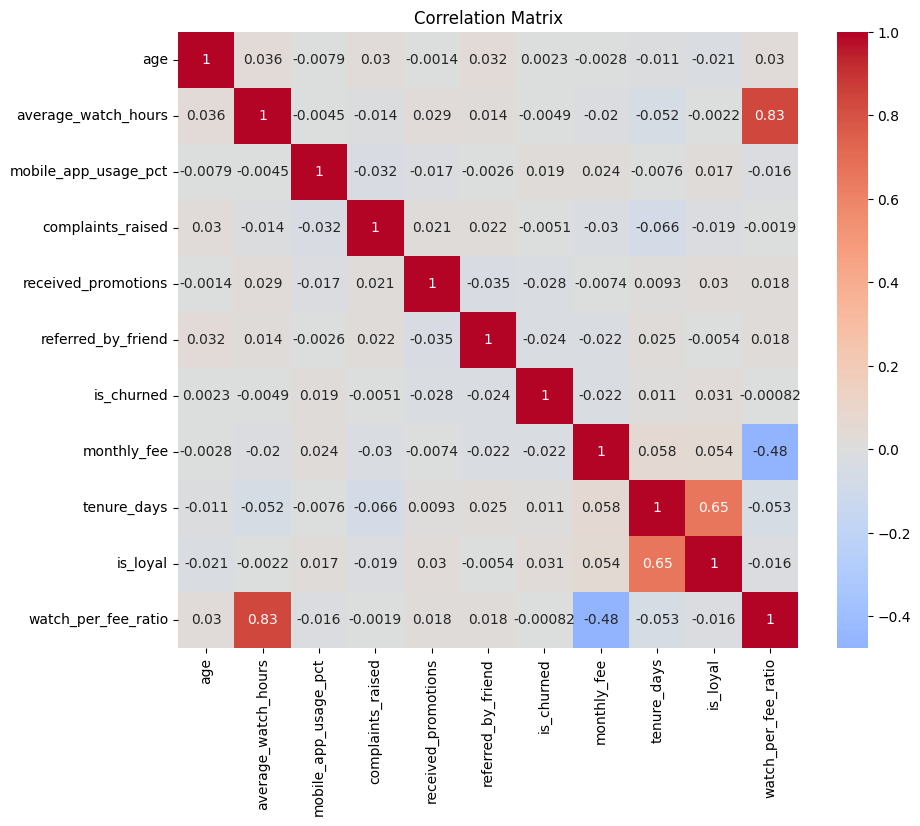

In [89]:
# 3. Create a correlation matrix and heatmap for numeric variables
numeric_cols = df_stream.select_dtypes(include=[np.number]).columns
correlation_matrix = df_stream[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()


In [90]:
# 4. Convert signup_date to datetime, and last_active_date to datetime
df_stream['signup_date'] = pd.to_datetime(df_stream['signup_date'], format='%d-%m-%y')
df_stream['last_active_date'] = pd.to_datetime(df_stream['last_active_date'], format='%d-%m-%y')


In [91]:
# 5. Creature new feature: 'tenure_days' = last_active_date - signup_date
df_stream['tenure_days'] = (df_stream['last_active_date'] - df_stream['signup_date']).dt.days
df_stream.head()

,age,signup_date,last_active_date,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee,...,country_France,country_Germany,country_India,country_UK,country_USA,watch_per_fee_ratio,heavy_mobile_user,age_group,watch_hours_group,watch_hours_bin
0,56.0,2025-04-02,2025-07-13,42.6,77.4,1.0,0,0,1.0,10.99,...,True,False,False,False,False,3.876248,True,46-60,10+,"(40.3, 47.9]"
1,69.0,2023-01-02,2025-07-13,65.3,98.0,4.0,0,1,1.0,5.99,...,False,False,True,False,False,10.901484,True,60+,10+,"(63.6, 71.16]"
2,46.0,2022-08-21,2025-07-13,40.1,47.8,0.0,0,1,1.0,13.99,...,False,False,False,True,False,2.866331,False,46-60,10+,"(32.4, 40.3]"
3,32.0,2023-09-14,2025-07-13,5.8,53.2,1.0,1,1,1.0,13.99,...,False,True,False,False,False,0.414582,True,31-45,5-10,"(0.499, 8.0]"
4,60.0,2023-07-29,2025-07-13,32.7,16.8,5.0,0,1,0.0,9.99,...,False,False,True,False,False,3.273270,False,46-60,10+,"(32.4, 40.3]"


In [92]:
# 6. Create a column is_loyal = tenure_days > 180
df_stream['is_loyal'] = df_stream['tenure_days'] > 180
df_stream.head()

,age,signup_date,last_active_date,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee,...,country_France,country_Germany,country_India,country_UK,country_USA,watch_per_fee_ratio,heavy_mobile_user,age_group,watch_hours_group,watch_hours_bin
0,56.0,2025-04-02,2025-07-13,42.6,77.4,1.0,0,0,1.0,10.99,...,True,False,False,False,False,3.876248,True,46-60,10+,"(40.3, 47.9]"
1,69.0,2023-01-02,2025-07-13,65.3,98.0,4.0,0,1,1.0,5.99,...,False,False,True,False,False,10.901484,True,60+,10+,"(63.6, 71.16]"
2,46.0,2022-08-21,2025-07-13,40.1,47.8,0.0,0,1,1.0,13.99,...,False,False,False,True,False,2.866331,False,46-60,10+,"(32.4, 40.3]"
3,32.0,2023-09-14,2025-07-13,5.8,53.2,1.0,1,1,1.0,13.99,...,False,True,False,False,False,0.414582,True,31-45,5-10,"(0.499, 8.0]"
4,60.0,2023-07-29,2025-07-13,32.7,16.8,5.0,0,1,0.0,9.99,...,False,False,True,False,False,3.273270,False,46-60,10+,"(32.4, 40.3]"


In [93]:
# Run this inside your notebook cell
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [94]:
#7. Encoding categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# Binary encoding for 'is_loyal', 'referred_by_friend', 'received_promotions'
binary_cols = ['is_loyal', 'referred_by_friend', 'received_promotions']
for col in binary_cols:
    df_stream[col] = le.fit_transform(df_stream[col])
# One-hot encoding for 'gender', 'subscription_type', 'country'
df_stream = pd.get_dummies(df_stream, columns=['gender', 'subscription_type', 'country'], drop_first=True)
df_stream.head()


KeyError: "None of [Index(['gender', 'subscription_type', 'country'], dtype='str')] are in the [columns]"

In [ ]:
# 7. Handle missing values

# Drop user_id safely (already dropped = no crash)
df_stream = df_stream.drop(columns=['user_id'], errors='ignore')

# Fill numeric nulls with median
df_stream['age']                  = df_stream['age'].fillna(df_stream['age'].median())
df_stream['average_watch_hours']  = df_stream['average_watch_hours'].fillna(df_stream['average_watch_hours'].median())
df_stream['mobile_app_usage_pct'] = df_stream['mobile_app_usage_pct'].fillna(df_stream['mobile_app_usage_pct'].median())
df_stream['complaints_raised']    = df_stream['complaints_raised'].fillna(df_stream['complaints_raised'].median())
df_stream['monthly_fee']          = df_stream['monthly_fee'].fillna(df_stream['monthly_fee'].median())

# Drop the single row with missing target variable
df_stream = df_stream.dropna(subset=['is_churned'])
# Drop rows where date columns are null
# (tenure_days nulls will also be resolved since they come from these dates)
df_stream = df_stream.dropna(subset=['signup_date', 'last_active_date', 'tenure_days'])

# Verify
print("Shape:", df_stream.shape)
print("\nRemaining nulls:\n", df_stream.isnull().sum())


Shape: (1495, 21)

Remaining nulls:
 age                           0
signup_date                   0
last_active_date              0
average_watch_hours           0
mobile_app_usage_pct          0
complaints_raised             0
received_promotions           0
referred_by_friend            0
is_churned                    0
monthly_fee                   0
tenure_days                   0
is_loyal                      0
gender_Male                   0
gender_Other                  0
subscription_type_Premium     0
subscription_type_Standard    0
country_France                0
country_Germany               0
country_India                 0
country_UK                    0
country_USA                   0
dtype: int64


In [ ]:
# 8. Create new features: 'watch_per_fee_ratio', 'heavy_mobile_user'
df_stream['watch_per_fee_ratio'] = df_stream['average_watch_hours'] / (df_stream['monthly_fee'] + 1e-5)  # Add small value to avoid division by zero
df_stream['heavy_mobile_user'] = df_stream['mobile_app_usage_pct'] > 50
df_stream.head()

,age,signup_date,last_active_date,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee,...,gender_Other,subscription_type_Premium,subscription_type_Standard,country_France,country_Germany,country_India,country_UK,country_USA,watch_per_fee_ratio,heavy_mobile_user
0,56.0,2025-04-02,2025-07-13,42.6,77.4,1.0,0,0,1.0,10.99,...,True,False,True,True,False,False,False,False,3.876248,True
1,69.0,2023-01-02,2025-07-13,65.3,98.0,4.0,0,1,1.0,5.99,...,False,False,False,False,False,True,False,False,10.901484,True
2,46.0,2022-08-21,2025-07-13,40.1,47.8,0.0,0,1,1.0,13.99,...,False,True,False,False,False,False,True,False,2.866331,False
3,32.0,2023-09-14,2025-07-13,5.8,53.2,1.0,1,1,1.0,13.99,...,True,True,False,False,True,False,False,False,0.414582,True
4,60.0,2023-07-29,2025-07-13,32.7,16.8,5.0,0,1,0.0,9.99,...,False,False,True,False,False,True,False,False,3.273270,False


In [ ]:
# 9. Grouping age and averag_watch_hours into buckets
df_stream['age_group'] = pd.cut(df_stream['age'], bins=[0, 18, 30, 45, 60, np.inf], labels=['0-18', '19-30', '31-45', '46-60', '60+'])
df_stream['watch_hours_group'] = pd.cut(df_stream['average_watch_hours'], bins=[0, 1, 3, 5, 10, np.inf], labels=['0-1', '1-3', '3-5', '5-10', '10+'])
df_stream.head()

,age,signup_date,last_active_date,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee,...,subscription_type_Standard,country_France,country_Germany,country_India,country_UK,country_USA,watch_per_fee_ratio,heavy_mobile_user,age_group,watch_hours_group
0,56.0,2025-04-02,2025-07-13,42.6,77.4,1.0,0,0,1.0,10.99,...,True,True,False,False,False,False,3.876248,True,46-60,10+
1,69.0,2023-01-02,2025-07-13,65.3,98.0,4.0,0,1,1.0,5.99,...,False,False,False,True,False,False,10.901484,True,60+,10+
2,46.0,2022-08-21,2025-07-13,40.1,47.8,0.0,0,1,1.0,13.99,...,False,False,False,False,True,False,2.866331,False,46-60,10+
3,32.0,2023-09-14,2025-07-13,5.8,53.2,1.0,1,1,1.0,13.99,...,False,False,True,False,False,False,0.414582,True,31-45,5-10
4,60.0,2023-07-29,2025-07-13,32.7,16.8,5.0,0,1,0.0,9.99,...,True,False,False,True,False,False,3.273270,False,46-60,10+


In [ ]:
# 10. Statistical analysis: Use chi square test to check if 'is_churned' is related to 'gender', 'receives_promotions', and 'referred_by_friend'
from scipy.stats import chi2_contingency
# Create contingency tables and perform chi-square test
categorical_cols = ['gender_Male', 'received_promotions', 'referred_by_friend']
for col in categorical_cols:
    contingency_table = pd.crosstab(df_stream['is_churned'], df_stream[col])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"Chi-square test for {col}:")
    print(f"Chi2 statistic: {chi2:.4f}, p-value: {p:.4f}\n")
    

Chi-square test for gender_Male:
Chi2 statistic: 0.8433, p-value: 0.3585

Chi-square test for received_promotions:
Chi2 statistic: 12.2207, p-value: 0.0022

Chi-square test for referred_by_friend:
Chi2 statistic: 1.3613, p-value: 0.5063



In [ ]:
pd.crosstab(df_stream['received_promotions'], df_stream['is_churned'], normalize='index')

is_churned,0.0,1.0
received_promotions,,
0,0.751643,0.248357
1,0.785226,0.214774
2,0.000000,1.000000


In [ ]:
# How many rows are actually in category 2, and what was the original raw value?
print(df_stream['received_promotions'].value_counts())

# If you still have access to the raw pre-encoded values (before LabelEncoder ran):
# check the original column for unexpected values like NaN, blank strings, or a third category

received_promotions
0    761
1    731
2      3
Name: count, dtype: int64


In [95]:
# Reload original CSV to see what the 3 anomalous rows actually contained
df_raw_check = pd.read_csv('streamworks_user_data.csv')  # adjust path if needed
print(df_raw_check['received_promotions'].value_counts(dropna=False))

received_promotions
No     763
Yes    734
NaN      3
Name: count, dtype: int64


In [119]:
# Option A: Drop the 3 problematic rows (simplest, minimal impact on ~1500 rows)
# First identify which rows have code 2 in your current df_stream
problem_rows = df_stream[df_stream['received_promotions'] == 2].index
df_stream_cleaned = df_stream.drop(index=problem_rows)
print(f"Dropped {len(problem_rows)} rows, new shape: {df_stream_cleaned.shape}")

Dropped 3 rows, new shape: (1492, 26)


In [130]:
# 10. Statistical analysis: Use chi square test to check if 'is_churned' is related to 'gender', 'receives_promotions', and 'referred_by_friend'
from scipy.stats import chi2_contingency
# Create contingency tables and perform chi-square test
categorical_cols = ['gender_Male', 'received_promotions', 'referred_by_friend']
for col in categorical_cols:
    contingency_table = pd.crosstab(df_stream['is_churned'], df_stream[col])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"Chi-square test for {col}:")
    print(f"Chi2 statistic: {chi2:.4f}, p-value: {p:.4f}\n")

Chi-square test for gender_Male:
Chi2 statistic: 0.8433, p-value: 0.3585

Chi-square test for received_promotions:
Chi2 statistic: 12.2207, p-value: 0.0022

Chi-square test for referred_by_friend:
Chi2 statistic: 1.3613, p-value: 0.5063



In [131]:
from scipy.stats import chi2_contingency

# Make sure this uses the CLEANED dataframe
categorical_cols = ['gender_Male', 'received_promotions', 'referred_by_friend']
for col in categorical_cols:
    contingency_table = pd.crosstab(df_stream_cleaned['is_churned'], df_stream_cleaned[col])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"Chi-square test for {col}:")
    print(f"Chi2 statistic: {chi2:.4f}, p-value: {p:.4f}\n")

Chi-square test for gender_Male:
Chi2 statistic: 0.6780, p-value: 0.4103

Chi-square test for received_promotions:
Chi2 statistic: 2.1760, p-value: 0.1402

Chi-square test for referred_by_friend:
Chi2 statistic: 1.2805, p-value: 0.5272



In [ ]:
# 11. Use t-test to see if watch time differ significantly between churned and retained users
from scipy.stats import ttest_ind
churned_watch_time = df_stream[df_stream['is_churned'] == 1]['average_watch_hours']
retained_watch_time = df_stream[df_stream['is_churned'] == 0]['average_watch_hours']
t_stat, p_value = ttest_ind(churned_watch_time, retained_watch_time, equal_var=False)  # Use Welch's t-test
print(f"T-test for average_watch_hours between churned and retained users:")
print(f"T-statistic: {t_stat:.4f}, p-value: {p_value:.4f}")

T-test for average_watch_hours between churned and retained users:
T-statistic: -0.1880, p-value: 0.8509


In [132]:
from scipy.stats import ttest_ind

churned = df_stream_cleaned[df_stream_cleaned['is_churned'] == 1]['average_watch_hours']
retained = df_stream_cleaned[df_stream_cleaned['is_churned'] == 0]['average_watch_hours']

t_stat, p_value = ttest_ind(churned, retained, equal_var=False)  # Welch's t-test, safer default

print(f"Churned mean watch hours: {churned.mean():.2f}")
print(f"Retained mean watch hours: {retained.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}, p-value: {p_value:.4f}")

Churned mean watch hours: 39.65
Retained mean watch hours: 39.98
T-statistic: -0.2313, p-value: 0.8172


In [155]:
contingency_table = pd.crosstab(df_stream['is_churned'], df_stream['heavy_mobile_user'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square test for heavy_mobile_user vs is_churned:")
print(f"Chi2 statistic: {chi2:.4f}, p-value: {p:.4f}\n")

# Churn rate by group, for direction/magnitude
print(pd.crosstab(df_stream['heavy_mobile_user'], df_stream['is_churned'], normalize='index'))

Chi-square test for heavy_mobile_user vs is_churned:
Chi2 statistic: 0.1645, p-value: 0.6850

is_churned              0.0       1.0
heavy_mobile_user                    
False              0.771955  0.228045
True               0.761724  0.238276


In [178]:
coef_df = pd.DataFrame({
    'feature': X_clean.columns,
    'coefficient': model_clean.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
print(coef_df)

                       feature  coefficient
9                 gender_Other    -0.179923
10   subscription_type_Premium    -0.156079
8                  gender_Male    -0.087970
12              country_France     0.084890
15                  country_UK     0.083370
6                  monthly_fee     0.083030
14               country_India     0.075550
11  subscription_type_Standard    -0.072681
5           referred_by_friend    -0.068652
7                  tenure_days     0.067230
4          received_promotions    -0.056886
16                 country_USA     0.049515
13             country_Germany     0.039278
2         mobile_app_usage_pct     0.027760
0                          age     0.022449
1          average_watch_hours    -0.005531
3            complaints_raised    -0.003056


In [201]:
X_clean = X.drop(columns=[
    'watch_per_fee_ratio',
    'is_loyal',
    'heavy_mobile_user',
    'watch_hours_bin_(8.0, 15.2]', 'watch_hours_bin_(15.2, 24.1]',
    'watch_hours_bin_(24.1, 32.4]', 'watch_hours_bin_(32.4, 40.3]',
    'watch_hours_bin_(40.3, 47.9]', 'watch_hours_bin_(47.9, 55.2]',
    'watch_hours_bin_(55.2, 63.6]', 'watch_hours_bin_(63.6, 71.16]',
    'watch_hours_bin_(71.16, 79.9]'
])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s = sc.transform(X_te)

model_clean = LogisticRegression(max_iter=1000, class_weight='balanced')
model_clean.fit(X_tr_s, y_tr)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [224]:
# Churn rate by subscription type (use original categorical column if available, else dummies)
print("Churn rate by subscription type:")
print(df_stream.groupby('subscription_type_Premium')['is_churned'].mean() 
      if 'subscription_type' not in df_stream.columns 
      else df_stream.groupby('subscription_type')['is_churned'].mean())

print("\nChurn rate by country:")
country_cols = ['country_France', 'country_Germany', 'country_India', 'country_UK', 'country_USA']
for col in country_cols:
    rate = df_stream[df_stream[col] == 1]['is_churned'].mean()
    print(f"{col}: {rate:.3f}")

print("\nChurn rate by gender:")
print(f"gender_Male=1: {df_stream[df_stream['gender_Male']==1]['is_churned'].mean():.3f}")
print(f"gender_Other=1: {df_stream[df_stream['gender_Other']==1]['is_churned'].mean():.3f}")
print(f"baseline (Female): {df_stream[(df_stream['gender_Male']==0)&(df_stream['gender_Other']==0)]['is_churned'].mean():.3f}")

# Overall churn rate for reference
print(f"\nOverall churn rate: {df_stream['is_churned'].mean():.3f}")

Churn rate by subscription type:
subscription_type_Premium
False    0.241968
True     0.216433
Name: is_churned, dtype: float64

Churn rate by country:
country_France: 0.237
country_Germany: 0.225
country_India: 0.241
country_UK: 0.274
country_USA: 0.213

Churn rate by gender:
gender_Male=1: 0.218
gender_Other=1: 0.217
baseline (Female): 0.265

Overall churn rate: 0.233


In [247]:
df_stream['age_bucket'] = pd.cut(df_stream['age'], bins=[0, 18, 30, 45, 60, np.inf])
print("Churn rate by age bucket:")
print(df_stream.groupby('age_bucket', observed=True)['is_churned'].mean())

print("\nCount per bucket (to check sample sizes):")
print(df_stream.groupby('age_bucket', observed=True)['is_churned'].count())

Churn rate by age bucket:
age_bucket
(0.0, 18.0]     0.212121
(18.0, 30.0]    0.228916
(30.0, 45.0]    0.245327
(45.0, 60.0]    0.234884
(60.0, inf]     0.220588
Name: is_churned, dtype: float64

Count per bucket (to check sample sizes):
age_bucket
(0.0, 18.0]      33
(18.0, 30.0]    332
(30.0, 45.0]    428
(45.0, 60.0]    430
(60.0, inf]     272
Name: is_churned, dtype: int64


C:\Users\burie\AppData\Local\Temp\ipykernel_12084\377200845.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([churned_watch_time, retained_watch_time], labels=['Churned', 'Retained'])


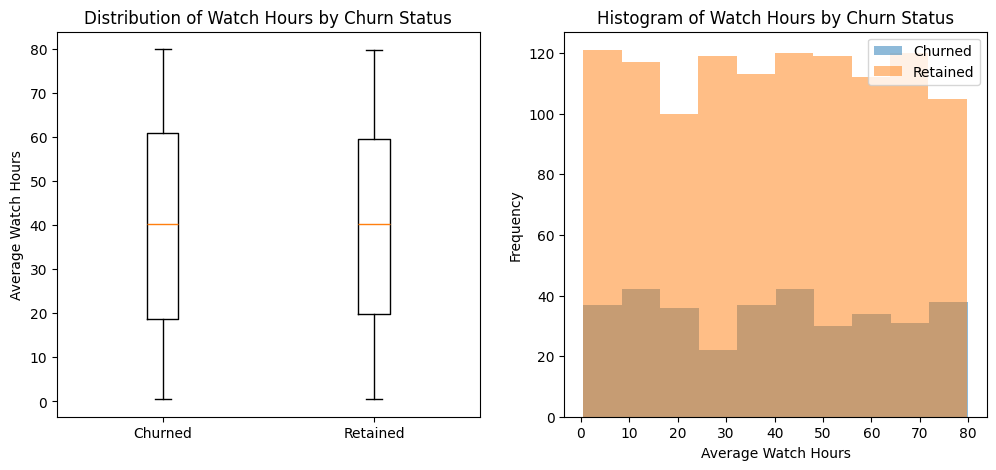

In [225]:
# 12. Draw a boxplot and histogram to visualize the key differences between churned and active users
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.boxplot([churned_watch_time, retained_watch_time], labels=['Churned', 'Retained'])
plt.ylabel('Average Watch Hours')
plt.title('Distribution of Watch Hours by Churn Status')
plt.subplot(1, 2, 2)
plt.hist(churned_watch_time, alpha=0.5, label='Churned')
plt.hist(retained_watch_time, alpha=0.5, label='Retained')
plt.xlabel('Average Watch Hours')
plt.ylabel('Frequency')
plt.title('Histogram of Watch Hours by Churn Status')
plt.legend()
plt.show()

In [226]:
# Logistic regression to predict is_churned
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd

# Prepare features and target variable
X = df_stream.drop(columns=[
    'is_churned', 'signup_date', 'last_active_date',
    'age_group', 'watch_hours_group'  # redundant bucketed versions of age / average_watch_hours
])
y = df_stream['is_churned']

# One-hot encode any remaining categorical columns (safe even if none are left)
X = pd.get_dummies(X, drop_first=True)

# Sanity check class balance
print("Class balance:")
print(y.value_counts(normalize=True))
print()

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression model
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("ROC AUC Score:")
print(roc_auc_score(y_test, y_pred_proba))

Class balance:
is_churned
0.0    0.766555
1.0    0.233445
Name: proportion, dtype: float64

Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.48      0.60       229
         1.0       0.24      0.54      0.34        70

    accuracy                           0.50       299
   macro avg       0.51      0.51      0.47       299
weighted avg       0.65      0.50      0.54       299

Confusion Matrix:
[[111 118]
 [ 32  38]]
ROC AUC Score:
0.5321896444167187


In [227]:
# Quick check: does any individual feature separate churners from non-churners?
for col in X.columns:
    print(col, df_stream.groupby('is_churned')[col].mean() if col in df_stream.columns else '(encoded)')

age is_churned
0.0    43.759162
1.0    43.839542
Name: age, dtype: float64
average_watch_hours is_churned
0.0    39.980628
1.0    39.714327
Name: average_watch_hours, dtype: float64
mobile_app_usage_pct is_churned
0.0    51.120332
1.0    52.380229
Name: mobile_app_usage_pct, dtype: float64
complaints_raised is_churned
0.0    2.501745
1.0    2.481375
Name: complaints_raised, dtype: float64
received_promotions is_churned
0.0    0.500873
1.0    0.467049
Name: received_promotions, dtype: float64
referred_by_friend is_churned
0.0    0.510471
1.0    0.481375
Name: referred_by_friend, dtype: float64
monthly_fee is_churned
0.0    10.206405
1.0    10.044441
Name: monthly_fee, dtype: float64
tenure_days is_churned
0.0    538.273124
1.0    546.687679
Name: tenure_days, dtype: float64
is_loyal is_churned
0.0    0.820244
1.0    0.848138
Name: is_loyal, dtype: float64
gender_Male is_churned
0.0    0.32897
1.0    0.30086
Name: gender_Male, dtype: float64
gender_Other is_churned
0.0    0.343805
1.0   

In [228]:
X_numeric = X.select_dtypes(include='number').copy()
X_numeric['is_churned'] = y.values
print(X_numeric.corr()['is_churned'].sort_values(ascending=False))

is_churned              1.000000
is_loyal                0.031178
mobile_app_usage_pct    0.018670
tenure_days             0.011229
age                     0.002257
watch_per_fee_ratio    -0.000823
average_watch_hours    -0.004907
complaints_raised      -0.005059
monthly_fee            -0.021776
referred_by_friend     -0.024486
received_promotions    -0.028392
Name: is_churned, dtype: float64


In [229]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)  # tree models don't need scaling
rf_pred_proba = rf.predict_proba(X_test)[:, 1]
print("RF ROC AUC:", roc_auc_score(y_test, rf_pred_proba))

RF ROC AUC: 0.5902370555208982


In [230]:
import pandas as pd
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(10))

mobile_app_usage_pct    0.125537
tenure_days             0.122598
watch_per_fee_ratio     0.119556
average_watch_hours     0.118519
age                     0.108957
complaints_raised       0.056866
monthly_fee             0.042307
received_promotions     0.026167
referred_by_friend      0.021301
gender_Male             0.020471
dtype: float64


In [231]:
from sklearn.model_selection import cross_val_score

rf_cv = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
scores = cross_val_score(rf_cv, X, y, cv=5, scoring='roc_auc')
print("CV AUC scores:", scores)
print("Mean:", scores.mean(), "Std:", scores.std())

CV AUC scores: [0.50948222 0.49525889 0.51475359 0.55177792 0.56269691]
Mean: 0.5267939052524784 Std: 0.0258934263096204


In [232]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf, X_test, y_test, n_repeats=20, random_state=42, scoring='roc_auc')
perm_importances = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
print(perm_importances.head(10))

watch_per_fee_ratio              0.044164
average_watch_hours              0.043790
mobile_app_usage_pct             0.038667
age                              0.019353
country_USA                      0.015741
watch_hours_bin_(32.4, 40.3]     0.009050
heavy_mobile_user                0.008710
referred_by_friend               0.007859
country_Germany                  0.007754
watch_hours_bin_(71.16, 79.9]    0.007210
dtype: float64


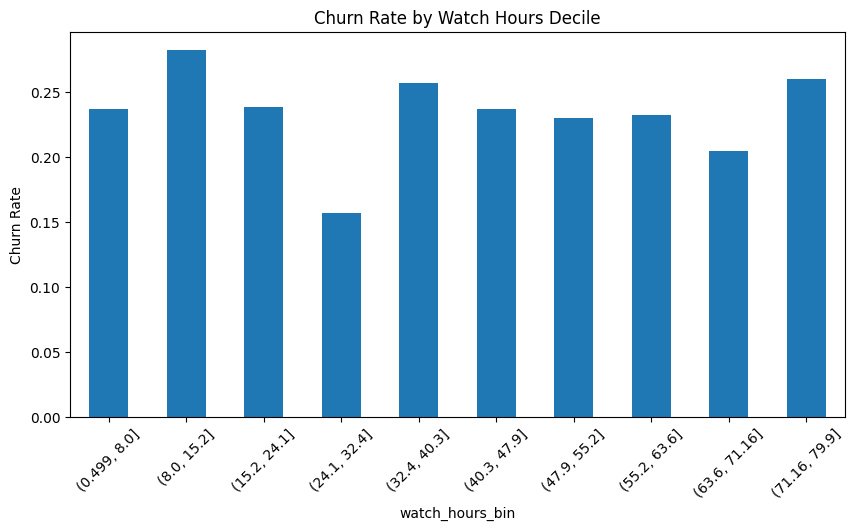

In [233]:
import matplotlib.pyplot as plt

df_stream['watch_hours_bin'] = pd.qcut(df_stream['average_watch_hours'], q=10, duplicates='drop')
churn_by_bin = df_stream.groupby('watch_hours_bin')['is_churned'].mean()
churn_by_bin.plot(kind='bar', figsize=(10,5))
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Watch Hours Decile')
plt.xticks(rotation=45)
plt.show()

In [234]:
from sklearn.model_selection import cross_val_score

rf_cv = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
scores = cross_val_score(rf_cv, X, y, cv=5, scoring='roc_auc')
print("CV AUC scores:", scores)
print("Mean:", scores.mean(), "Std:", scores.std())

CV AUC scores: [0.50948222 0.49525889 0.51475359 0.55177792 0.56269691]
Mean: 0.5267939052524784 Std: 0.0258934263096204


In [235]:
X = df_stream.drop(columns=[
    'is_churned', 'signup_date', 'last_active_date',
    'age_group', 'watch_hours_group'
])
y = df_stream['is_churned']
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

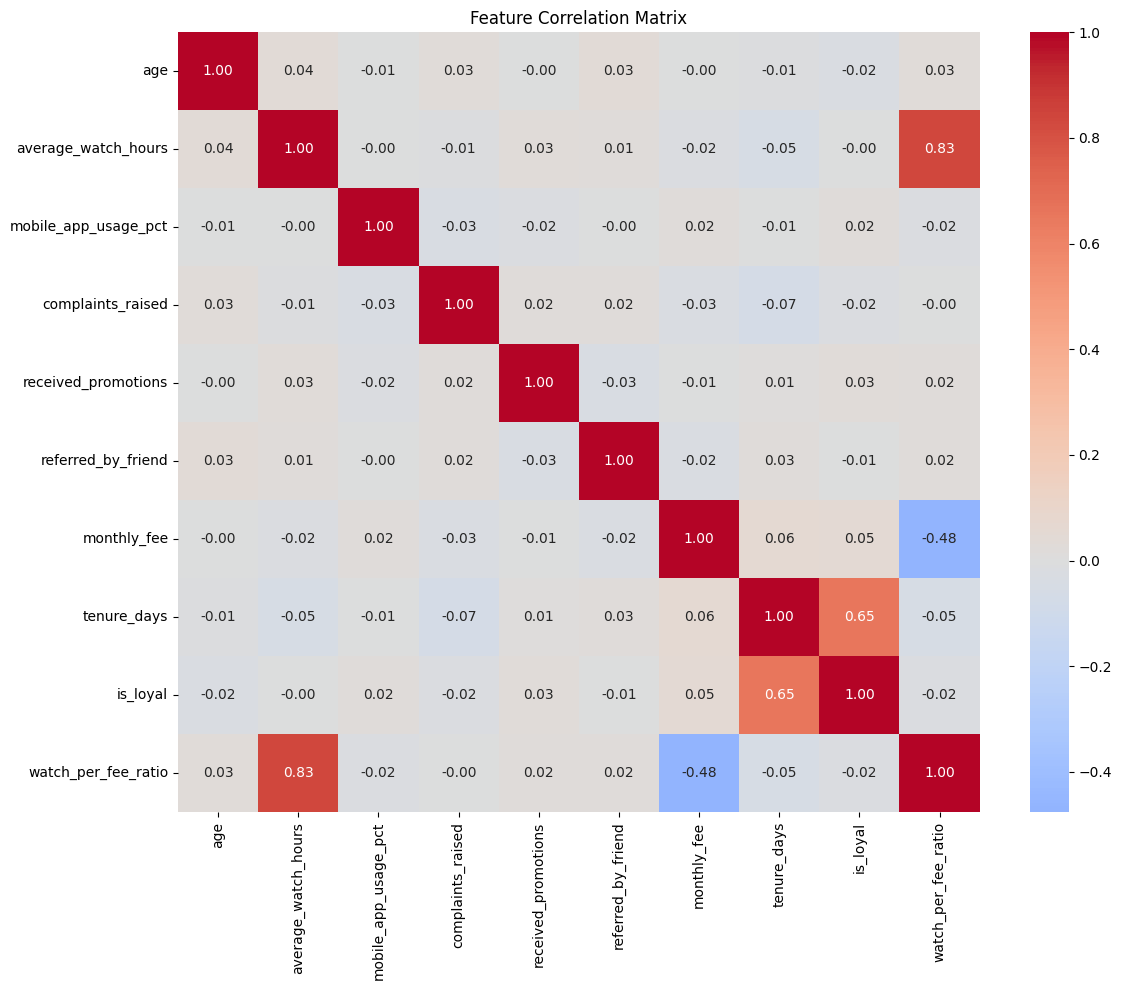

Top correlated feature pairs:
average_watch_hours  watch_per_fee_ratio    0.834340
watch_per_fee_ratio  average_watch_hours    0.834340
is_loyal             tenure_days            0.654848
tenure_days          is_loyal               0.654848
monthly_fee          watch_per_fee_ratio    0.475553
watch_per_fee_ratio  monthly_fee            0.475553
complaints_raised    tenure_days            0.065860
tenure_days          complaints_raised      0.065860
monthly_fee          tenure_days            0.057957
tenure_days          monthly_fee            0.057957
dtype: float64


In [236]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix of your features (numeric only)
plt.figure(figsize=(12, 10))
corr_matrix = X.select_dtypes(include='number').corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Print out the highest pairwise correlations (excluding self-correlation)
corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]  # remove self-correlations (always 1.0)
print("Top correlated feature pairs:")
print(corr_pairs.head(10))

In [237]:
# Drop one of each correlated pair and refit
X_reduced = X.drop(columns=['watch_per_fee_ratio', 'is_loyal'])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

model_reduced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_reduced.fit(X_train_r_scaled, y_train_r)

y_pred_proba_r = model_reduced.predict_proba(X_test_r_scaled)[:, 1]
print("Reduced-feature Logistic Regression ROC AUC:")
print(roc_auc_score(y_test_r, y_pred_proba_r))

Reduced-feature Logistic Regression ROC AUC:
0.5271990018714909


In [238]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train_r, y_train_r)
y_pred_proba_rf = rf.predict_proba(X_test_r)[:, 1]
print("Random Forest ROC AUC:")
print(roc_auc_score(y_test_r, y_pred_proba_rf))

importances = pd.Series(rf.feature_importances_, index=X_train_r.columns).sort_values(ascending=False)
print(importances.head(10))

Random Forest ROC AUC:
0.5558951965065502
mobile_app_usage_pct    0.147340
tenure_days             0.142902
average_watch_hours     0.141241
age                     0.121499
complaints_raised       0.064525
monthly_fee             0.050467
received_promotions     0.028008
referred_by_friend      0.024055
gender_Male             0.021749
gender_Other            0.021200
dtype: float64


In [239]:
# List all column names in X
print(X.columns.tolist())

# Or with count
print(f"Total features: {len(X.columns)}")
print(X.columns.tolist())

['age', 'average_watch_hours', 'mobile_app_usage_pct', 'complaints_raised', 'received_promotions', 'referred_by_friend', 'monthly_fee', 'tenure_days', 'is_loyal', 'gender_Male', 'gender_Other', 'subscription_type_Premium', 'subscription_type_Standard', 'country_France', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'watch_per_fee_ratio', 'heavy_mobile_user', 'watch_hours_bin_(8.0, 15.2]', 'watch_hours_bin_(15.2, 24.1]', 'watch_hours_bin_(24.1, 32.4]', 'watch_hours_bin_(32.4, 40.3]', 'watch_hours_bin_(40.3, 47.9]', 'watch_hours_bin_(47.9, 55.2]', 'watch_hours_bin_(55.2, 63.6]', 'watch_hours_bin_(63.6, 71.16]', 'watch_hours_bin_(71.16, 79.9]']
Total features: 29
['age', 'average_watch_hours', 'mobile_app_usage_pct', 'complaints_raised', 'received_promotions', 'referred_by_friend', 'monthly_fee', 'tenure_days', 'is_loyal', 'gender_Male', 'gender_Other', 'subscription_type_Premium', 'subscription_type_Standard', 'country_France', 'country_Germany', 'country_India', 'coun

In [240]:
df_stream.groupby('heavy_mobile_user')['mobile_app_usage_pct'].describe()

,count,mean,std,min,25%,50%,75%,max
heavy_mobile_user,,,,,,,,
False,706.0,25.360482,14.581848,0.0,12.6,25.3,38.5,50.0
True,789.0,74.727630,14.263401,50.1,62.2,74.9,86.9,100.0


In [241]:
X_clean = X.drop(columns=[
    'watch_per_fee_ratio',      # derived from average_watch_hours & monthly_fee
    'is_loyal',                  # derived from tenure_days
    'heavy_mobile_user',         # derived from mobile_app_usage_pct > 50
    'watch_hours_bin_(8.0, 15.2]', 'watch_hours_bin_(15.2, 24.1]',
    'watch_hours_bin_(24.1, 32.4]', 'watch_hours_bin_(32.4, 40.3]',
    'watch_hours_bin_(40.3, 47.9]', 'watch_hours_bin_(47.9, 55.2]',
    'watch_hours_bin_(55.2, 63.6]', 'watch_hours_bin_(63.6, 71.16]',
    'watch_hours_bin_(71.16, 79.9]'
])

print(f"Remaining features: {len(X_clean.columns)}")
print(X_clean.columns.tolist())

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s = sc.transform(X_te)

model_clean = LogisticRegression(max_iter=1000, class_weight='balanced')
model_clean.fit(X_tr_s, y_tr)
proba_clean = model_clean.predict_proba(X_te_s)[:, 1]
print("Cleaned Logistic Regression ROC AUC:", roc_auc_score(y_te, proba_clean))

Remaining features: 17
['age', 'average_watch_hours', 'mobile_app_usage_pct', 'complaints_raised', 'received_promotions', 'referred_by_friend', 'monthly_fee', 'tenure_days', 'gender_Male', 'gender_Other', 'subscription_type_Premium', 'subscription_type_Standard', 'country_France', 'country_Germany', 'country_India', 'country_UK', 'country_USA']
Cleaned Logistic Regression ROC AUC: 0.5053649407361198


In [242]:
X_binary_only = X.drop(columns=[
    'average_watch_hours',   # replaced by watch_hours_bin_* dummies
    'tenure_days',            # replaced by is_loyal
    'mobile_app_usage_pct',   # replaced by heavy_mobile_user
    'watch_per_fee_ratio'     # drop this one either way, still redundant with monthly_fee/watch hours
])

print(f"Remaining features: {len(X_binary_only.columns)}")
print(X_binary_only.columns.tolist())

X_tr, X_te, y_tr, y_te = train_test_split(
    X_binary_only, y, test_size=0.2, random_state=42, stratify=y
)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s = sc.transform(X_te)

model_binary = LogisticRegression(max_iter=1000, class_weight='balanced')
model_binary.fit(X_tr_s, y_tr)
proba_binary = model_binary.predict_proba(X_te_s)[:, 1]
print("Binary/Binned-only Logistic Regression ROC AUC:", roc_auc_score(y_te, proba_binary))

Remaining features: 25
['age', 'complaints_raised', 'received_promotions', 'referred_by_friend', 'monthly_fee', 'is_loyal', 'gender_Male', 'gender_Other', 'subscription_type_Premium', 'subscription_type_Standard', 'country_France', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'heavy_mobile_user', 'watch_hours_bin_(8.0, 15.2]', 'watch_hours_bin_(15.2, 24.1]', 'watch_hours_bin_(24.1, 32.4]', 'watch_hours_bin_(32.4, 40.3]', 'watch_hours_bin_(40.3, 47.9]', 'watch_hours_bin_(47.9, 55.2]', 'watch_hours_bin_(55.2, 63.6]', 'watch_hours_bin_(63.6, 71.16]', 'watch_hours_bin_(71.16, 79.9]']
Binary/Binned-only Logistic Regression ROC AUC: 0.5371179039301309


In [243]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Example for tenure_days as target
X_lin = df_stream.drop(columns=[
    'is_churned', 'signup_date', 'last_active_date',
    'tenure_days', 'is_loyal',  # is_loyal is derived from tenure_days — must drop to avoid leakage
    'age_group', 'watch_hours_group'
])
y_lin = df_stream['tenure_days']

X_lin = pd.get_dummies(X_lin, drop_first=True)

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42
)

scaler_l = StandardScaler()
X_train_l_scaled = scaler_l.fit_transform(X_train_l)
X_test_l_scaled = scaler_l.transform(X_test_l)

lin_model = LinearRegression()
lin_model.fit(X_train_l_scaled, y_train_l)

y_pred_l = lin_model.predict(X_test_l_scaled)

print("R²:", r2_score(y_test_l, y_pred_l))
print("RMSE:", np.sqrt(mean_squared_error(y_test_l, y_pred_l)))
print("MAE:", mean_absolute_error(y_test_l, y_pred_l))

R²: -0.016713056967199158
RMSE: 319.1890100080186
MAE: 275.183915217257


In [244]:
# 1. Confirm target range/distribution looks sensible
print(y_lin.describe())

# 2. Confirm no leakage columns snuck back in
print(X_lin.columns.tolist())

# 3. Try the simplest possible check — correlations with tenure_days directly
X_lin.select_dtypes(include='number').corrwith(y_lin).sort_values(key=abs, ascending=False)

count    1495.000000
mean      540.237458
std       317.108315
min         1.000000
25%       258.500000
50%       540.000000
75%       809.500000
max      1095.000000
Name: tenure_days, dtype: float64
['age', 'average_watch_hours', 'mobile_app_usage_pct', 'complaints_raised', 'received_promotions', 'referred_by_friend', 'monthly_fee', 'gender_Male', 'gender_Other', 'subscription_type_Premium', 'subscription_type_Standard', 'country_France', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'watch_per_fee_ratio', 'heavy_mobile_user', 'watch_hours_bin_(8.0, 15.2]', 'watch_hours_bin_(15.2, 24.1]', 'watch_hours_bin_(24.1, 32.4]', 'watch_hours_bin_(32.4, 40.3]', 'watch_hours_bin_(40.3, 47.9]', 'watch_hours_bin_(47.9, 55.2]', 'watch_hours_bin_(55.2, 63.6]', 'watch_hours_bin_(63.6, 71.16]', 'watch_hours_bin_(71.16, 79.9]']


complaints_raised      -0.065860
monthly_fee             0.057957
watch_per_fee_ratio    -0.052984
average_watch_hours    -0.052346
referred_by_friend      0.025138
age                    -0.011013
received_promotions     0.009312
mobile_app_usage_pct   -0.007590
dtype: float64

In [245]:
X_lin.select_dtypes(include='number').corrwith(y_lin).sort_values(key=abs, ascending=False)


complaints_raised      -0.065860
monthly_fee             0.057957
watch_per_fee_ratio    -0.052984
average_watch_hours    -0.052346
referred_by_friend      0.025138
age                    -0.011013
received_promotions     0.009312
mobile_app_usage_pct   -0.007590
dtype: float64

In [246]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train_l, y_train_l)
y_pred_rf_reg = rf_reg.predict(X_test_l)

print("Random Forest R²:", r2_score(y_test_l, y_pred_rf_reg))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test_l, y_pred_rf_reg)))

Random Forest R²: -0.08030289095568244
Random Forest RMSE: 329.0193942212918
